In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vishardmehta/faang-stock-market-data-with-technical-indicators")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Abhishek\.cache\kagglehub\datasets\vishardmehta\faang-stock-market-data-with-technical-indicators\versions\1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('faang_stock_prices.csv', index_col = 'Date')

In [4]:
df.head(20)

,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
Date,,,,,,,,,,,,,,,,,,
2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239
2016-02-23,NVDA,0.762756,0.778123,0.759097,0.770805,369380000,0.710800,0.683503,0.704268,0.691066,67.878773,0.013203,-0.001797,0.780719,0.585314,0.002538,0.028025,0.776172
2016-02-24,AAPL,21.304558,21.848618,21.154940,21.785145,145022800,21.850879,21.652174,21.730120,21.824170,50.813846,-0.094050,-0.138761,22.239524,20.975578,0.014891,0.018822,21.934757
2016-02-24,AMZN,27.287500,27.713499,26.657499,27.702000,124634000,27.011286,27.039167,26.909403,27.388874,57.060308,-0.479471,-0.812903,30.743809,23.032192,0.001989,0.022784,27.757500
2016-02-24,GOOGL,35.264055,35.790579,34.837779,35.774696,37092000,35.846794,36.102505,35.805323,36.001745,38.371697,-0.196422,-0.214611,38.407721,33.766104,0.005033,0.015166,36.182617


In [5]:
# already made dataset, so no need for feature engineering

In [6]:
df['Ticker'].value_counts()

Ticker
AAPL     2494
AMZN     2494
GOOGL    2494
META     2494
MSFT     2494
NVDA     2494
Name: count, dtype: int64

In [7]:
len(df)

14964

In [8]:
df['Ticker'].value_counts()

Ticker
AAPL     2494
AMZN     2494
GOOGL    2494
META     2494
MSFT     2494
NVDA     2494
Name: count, dtype: int64

In [9]:
2494/(365)

6.832876712328767

In [10]:
# 6.83 years of data

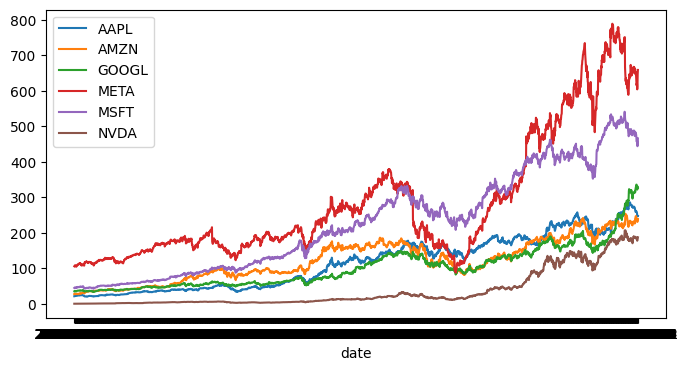

In [11]:
tickers = df['Ticker'].unique()
plt.figure(figsize = (8,4))
for t in tickers:
    sub = df[df['Ticker'] == t]
    plt.plot(sub.index, sub['Next_Day_Close'], label = t)
plt.xlabel('date')
plt.legend()
plt.show()

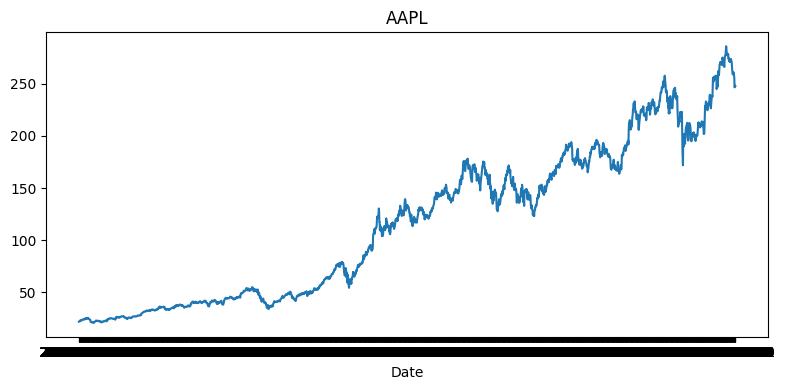

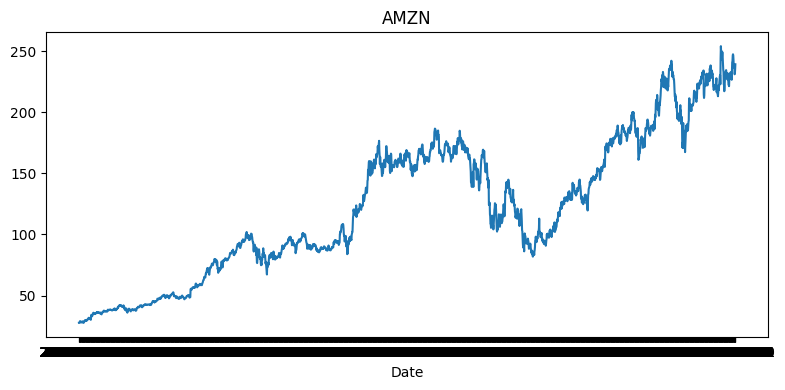

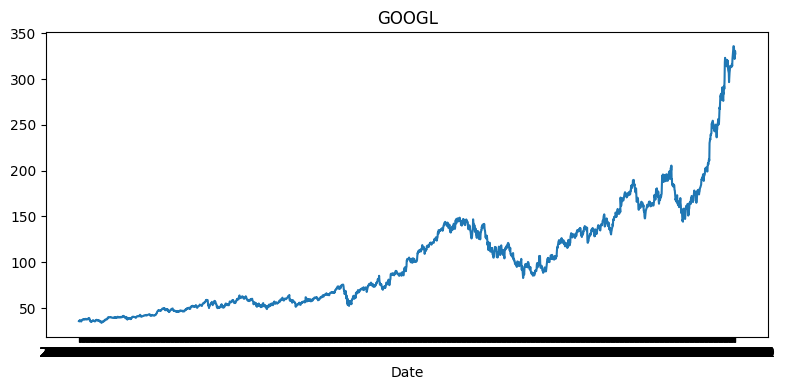

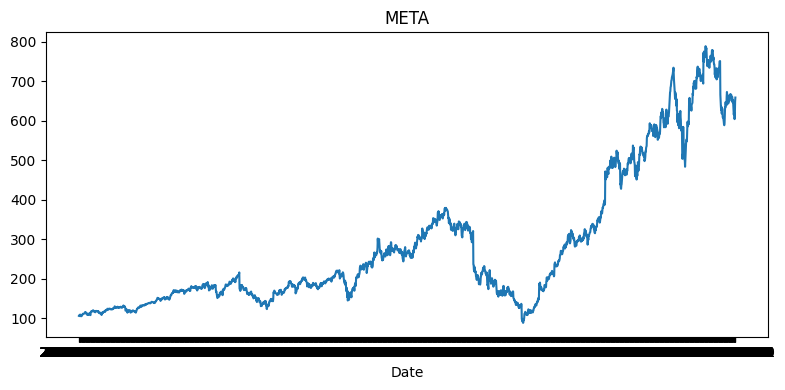

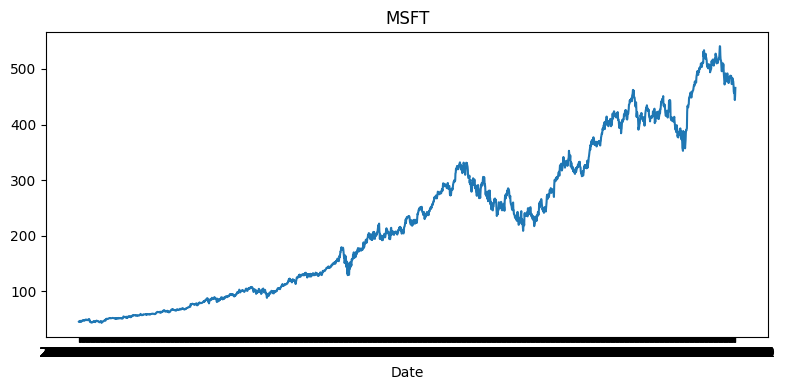

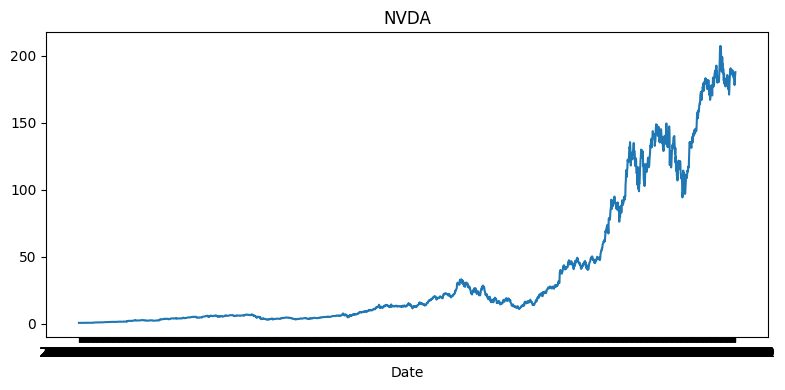

In [12]:
for t in tickers:
    sub = df[df["Ticker"] == t]
    plt.figure(figsize=(8,4))
    plt.plot(sub.index, sub["Next_Day_Close"])
    plt.title(t)
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

In [13]:
# one hot encoding the ticker column

In [14]:
one_hot_ticker = pd.get_dummies(df['Ticker']).astype('int32')

In [15]:
one_hot_ticker

,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Date,,,,,,
2016-02-23,1,0,0,0,0,0
2016-02-23,0,1,0,0,0,0
2016-02-23,0,0,1,0,0,0
2016-02-23,0,0,0,1,0,0
2016-02-23,0,0,0,0,1,0
...,...,...,...,...,...,...
2026-01-22,0,1,0,0,0,0
2026-01-22,0,0,1,0,0,0
2026-01-22,0,0,0,1,0,0


In [16]:
df = df.drop('Ticker', axis = 1)
df = pd.concat([df, one_hot_ticker], axis = 1)

In [17]:
df.head(10)

,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,...,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Date,,,,,,,,,,,,,,,,,,,,,
2016-02-23,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,...,20.889519,-0.022605,0.018130,21.785145,1,0,0,0,0,0
2016-02-23,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,...,22.908382,-0.011725,0.022486,27.702000,0,1,0,0,0,0
2016-02-23,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,...,33.798573,-0.016131,0.015153,35.774696,0,0,1,0,0,0
2016-02-23,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,...,92.886882,-0.015864,0.019720,106.138588,0,0,0,1,0,0
2016-02-23,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,...,42.459504,-0.027920,0.019161,45.294239,0,0,0,0,1,0
2016-02-23,0.762756,0.778123,0.759097,0.770805,369380000,0.710800,0.683503,0.704268,0.691066,67.878773,...,0.585314,0.002538,0.028025,0.776172,0,0,0,0,0,1
2016-02-24,21.304558,21.848618,21.154940,21.785145,145022800,21.850879,21.652174,21.730120,21.824170,50.813846,...,20.975578,0.014891,0.018822,21.934757,1,0,0,0,0,0
2016-02-24,27.287500,27.713499,26.657499,27.702000,124634000,27.011286,27.039167,26.909403,27.388874,57.060308,...,23.032192,0.001989,0.022784,27.757500,0,1,0,0,0,0
2016-02-24,35.264055,35.790579,34.837779,35.774696,37092000,35.846794,36.102505,35.805323,36.001745,38.371697,...,33.766104,0.005033,0.015166,36.182617,0,0,1,0,0,0


In [18]:
len(df)

14964

In [19]:
0.3*len(df)

4489.2

In [20]:
test_ind = 4490

In [21]:
xtrain = df[:-4990]
len(xtrain)

9974

In [22]:
xtest = df[-4990:]

In [23]:
len(xtest)

4990

In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
scaler = MinMaxScaler()
xtr_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

In [26]:
from tensorflow.keras.utils import timeseries_dataset_from_array

C:\Users\Abhishek\tf-env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [27]:
dataset_train = timeseries_dataset_from_array(data=xtr_scaled, targets=xtrain['Next_Day_Close'], sequence_length= 128)

In [28]:
dataset_test = timeseries_dataset_from_array(data=xtest_scaled, targets=xtest['Next_Day_Close'], sequence_length=128)

In [29]:
dataset_train.element_spec

(TensorSpec(shape=(None, None, 23), dtype=tf.float64, name=None),
 TensorSpec(shape=(None,), dtype=tf.float64, name=None))

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout

In [31]:
from tensorflow.keras.optimizers import Adam

In [32]:
predictor = Sequential()

predictor.add(Input(shape=[128,23]))
#predictor.add(LSTM(128,dropout=0.2, recurrent_dropout=0.2, recurrent_initializer='glorot_uniform', return_sequences=True))
predictor.add(LSTM(64,dropout=0.1, recurrent_dropout=0.1, recurrent_initializer='glorot_uniform'))
#predictor.add(LSTM(32,dropout=0.2, recurrent_dropout=0.2, recurrent_initializer='glorot_uniform'))
predictor.add(Dense(32, activation='relu'))
predictor.add(Dense(16, activation='relu'))

predictor.add(Dense(1,))

predictor.compile(loss='mse', optimizer = Adam(learning_rate= 1e-4))

In [33]:
predictor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          22,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,153 (98.25 KB)

 Trainable params: 25,153 (98.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

In [35]:
Early_stop = EarlyStopping(patience = 15, restore_best_weights=True, mode= 'min' )

In [ ]:
predictor.fit(dataset_train, validation_data= dataset_test, epochs=1000, callbacks=[Early_stop])

Epoch 1/1000
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 16317.0332 - val_loss: 82758.1094
Epoch 2/1000
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 15657.9648 - val_loss: 80584.6641
Epoch 3/1000
32/77 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 3488.1001

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [ ]:
predictor.evaluate(dataset_test)

In [ ]:
metrics = pd.DataFrame(predictor.history.history)

In [ ]:
metrics.plot()

In [ ]:
x_list, y_list = [], []
for x_batch, y_batch in dataset_test:
    x_list.append(x_batch.numpy())
    y_list.append(y_batch.numpy())

In [ ]:
x_seq = np.concatenate(x_list, axis=0)  
y_true = np.concatenate(y_list, axis=0)

In [ ]:
x_seq.shape

In [ ]:
y_true.shape

In [ ]:
pred = predictor.predict(x_seq)

In [ ]:
#pred = scaler.inverse_transform(pred)
pred

In [ ]:
y_true

In [ ]:
y_true = np.ravel(y_true)
pred   = np.ravel(pred)

In [ ]:
next_day_close_rmse = root_mean_squared_error(y_true, pred)
next_day_close_rmse

In [ ]:
next_day_close_mae = mean_absolute_error(y_true, pred)
next_day_close_mae

In [ ]:
# this was from calculating the raw data 'next day close', now we do the same , but with feature engineered 'next day return'

In [ ]:
df.head()

In [ ]:
df["log_next_return"] = np.log(df["Next_Day_Close"]) - np.log(df["Close"])

In [ ]:
df.head()

In [ ]:
#new model will predict log returns, and we will reproduce next day close value

In [ ]:
ground_truth = df['Next_Day_Close']

In [ ]:
label = df['log_next_return']

In [ ]:
data = df.drop(['Next_Day_Close','log_next_return'], axis = 1)

In [ ]:
xtrain = data[:-test_ind]
len(xtrain)

In [ ]:
xtest = data[-test_ind:]

In [ ]:
len(xtest)

In [ ]:
ytrain=label[:-test_ind]
len(ytrain)

In [ ]:
ytrain

In [ ]:
ytest= label[-test_ind:]
len(ytest)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
scaled_xtrain = scaler.fit_transform(xtrain)
scaled_xtest = scaler.transform(xtest)

In [ ]:
dataset_train = timeseries_dataset_from_array(data=scaled_xtrain, targets=ytrain, sequence_length= 128)
dataset_test = timeseries_dataset_from_array(data=scaled_xtest, targets=ytest, sequence_length= 128)

In [ ]:
dataset_train.element_spec

In [ ]:
predictor = Sequential()

predictor.add(Input(shape=[128,22]))
#predictor.add(LSTM(128,dropout=0.2, recurrent_dropout=0.2, recurrent_initializer='glorot_uniform', return_sequences=True))
predictor.add(LSTM(64,dropout=0.1, recurrent_dropout=0.1, recurrent_initializer='glorot_uniform'))
#predictor.add(LSTM(32,dropout=0.2, recurrent_dropout=0.2, recurrent_initializer='glorot_uniform'))
predictor.add(Dense(32, activation='relu'))
predictor.add(Dense(16, activation='relu'))

predictor.add(Dense(1,))

predictor.compile(loss='mse', optimizer = Adam(learning_rate= 1e-4))

In [ ]:
predictor.summary()

In [ ]:
Early_stop = EarlyStopping(patience = 15, restore_best_weights=True, mode= 'min' )

In [ ]:
predictor.fit(dataset_train, validation_data= dataset_test, epochs=1000, callbacks=[Early_stop])

In [ ]:
metrics = pd.DataFrame(predictor.history.history)

In [ ]:
metrics.plot()

In [ ]:
list_x = []
list_y = []
for x_batch, y_batch in dataset_train:
    list_x.append(x_batch.numpy())
    list_y.append(y_batch.numpy())

In [ ]:
x_seq = np.concatenate(list_x)
y_true = np.concatenate(list_y)

In [ ]:
x_seq.shape

In [ ]:
y_true.shape

In [ ]:
predictor.evaluate(x_seq,y_true)

In [ ]:
pred = predictor.predict(x_seq)

In [ ]:
pred = pred.ravel()

In [ ]:
# these are log next returns, what we want is the true values of next day close

In [ ]:
10474-10347

In [ ]:
close = xtrain['Close'][:-127]

In [ ]:
close

In [ ]:
pred_close = close * np.exp(pred)
pred_close

In [ ]:
ground_truth

In [ ]:
14964 - 10347

In [ ]:
final_truth = ground_truth[:-4617]

In [ ]:
final_truth

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(final_truth.index, final_truth.values, label='truth', color='blue', linewidth=1.5)
plt.plot(pred_close.index, pred_close.values, label='pred', color='orange', linewidth=1.2, alpha=0.8)

plt.title('Next-day Close: True vs Predicted (log-return model)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
root_mean_squared_error(final_truth, pred_close)

In [ ]:
mean_absolute_error(final_truth, pred_close)